In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries are working successfully!")

All libraries are working successfully!


In [117]:
# Create the student performance dataset

data = {
    "Student_ID": range(1, 21),
    "Gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"
    ],
    "Study_Hours": [
        2, 5, 3, 6, 4,
        7, 2, 8, 5, 3,
        6, 4, 7, 2, 5,
        8, 3, 6, 4, 7
    ],
    "Attendance": [
        75, 85, 80, 90, 88,
        95, 70, 98, 92, 78,
        89, 84, 96, 72, 87,
        99, 76, 93, 85, 91
    ],
    "Math_Score": [
        65, 78, 70, 85, 75,
        90, 60, 95, 88, 68,
        82, 76, 91, 62, 79,
        96, 67, 89, 74, 86
    ],
    "English_Score": [
        70, 80, 72, 88, 78,
        92, 65, 96, 90, 71,
        85, 79, 94, 64, 82,
        98, 69, 91, 77, 89
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

df.head()

Dataset created successfully!


,Student_ID,Gender,Study_Hours,Attendance,Math_Score,English_Score
0,1,Female,2,75,65,70
1,2,Male,5,85,78,80
2,3,Female,3,80,70,72
3,4,Male,6,90,85,88
4,5,Female,4,88,75,78


In [118]:
# ============================================================
# CHECK DATASET STRUCTURE AND DATA QUALITY
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(20, 6)

Column Names:
['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Math_Score', 'English_Score']

Data Types:
Student_ID       int64
Gender             str
Study_Hours      int64
Attendance       int64
Math_Score       int64
English_Score    int64
dtype: object

Missing Values:
Student_ID       0
Gender           0
Study_Hours      0
Attendance       0
Math_Score       0
English_Score    0
dtype: int64

Duplicate Rows:
0


In [119]:
# ============================================================
# DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates()

# Convert numerical columns to the correct data types
df["Student_ID"] = df["Student_ID"].astype(int)
df["Study_Hours"] = df["Study_Hours"].astype(float)
df["Attendance"] = df["Attendance"].astype(float)
df["Math_Score"] = df["Math_Score"].astype(float)
df["English_Score"] = df["English_Score"].astype(float)

print("Data cleaning completed successfully!")

print("\nFinal number of rows:", len(df))
print("Final number of columns:", len(df.columns))

Data cleaning completed successfully!

Final number of rows: 20
Final number of columns: 6


In [120]:
# ============================================================
# CALCULATE AVERAGE SCORE
# ============================================================

df["Average_Score"] = (
    df["Math_Score"] + df["English_Score"]
) / 2

print("Average score calculated successfully!")

df.head()

Average score calculated successfully!


,Student_ID,Gender,Study_Hours,Attendance,Math_Score,English_Score,Average_Score
0,1,Female,2.0,75.0,65.0,70.0,67.5
1,2,Male,5.0,85.0,78.0,80.0,79.0
2,3,Female,3.0,80.0,70.0,72.0,71.0
3,4,Male,6.0,90.0,85.0,88.0,86.5
4,5,Female,4.0,88.0,75.0,78.0,76.5


In [121]:
# ============================================================
# BASIC DATA ANALYSIS
# ============================================================

print("Average Math Score:",
      round(df["Math_Score"].mean(), 2))

print("Average English Score:",
      round(df["English_Score"].mean(), 2))

print("Overall Average Score:",
      round(df["Average_Score"].mean(), 2))

print("Average Study Hours:",
      round(df["Study_Hours"].mean(), 2))

print("Average Attendance:",
      round(df["Attendance"].mean(), 2))

Average Math Score: 78.8
Average English Score: 81.5
Overall Average Score: 80.15
Average Study Hours: 4.85
Average Attendance: 86.15


In [122]:
# ============================================================
# TOP 5 PERFORMING STUDENTS
# ============================================================

top_students = df.sort_values(
    by="Average_Score",
    ascending=False
).head(5)

print("Top 5 Performing Students:")

top_students[[
    "Student_ID",
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "English_Score",
    "Average_Score"
]]

Top 5 Performing Students:


,Student_ID,Study_Hours,Attendance,Math_Score,English_Score,Average_Score
15,16,8.0,99.0,96.0,98.0,97.0
7,8,8.0,98.0,95.0,96.0,95.5
12,13,7.0,96.0,91.0,94.0,92.5
5,6,7.0,95.0,90.0,92.0,91.0
17,18,6.0,93.0,89.0,91.0,90.0


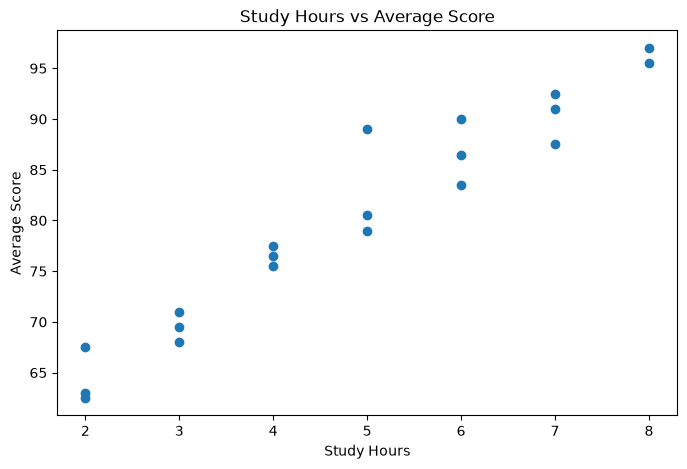

In [123]:
# ============================================================
# CHART 1: STUDY HOURS VS AVERAGE SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Average_Score"]
)

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")

plt.show()

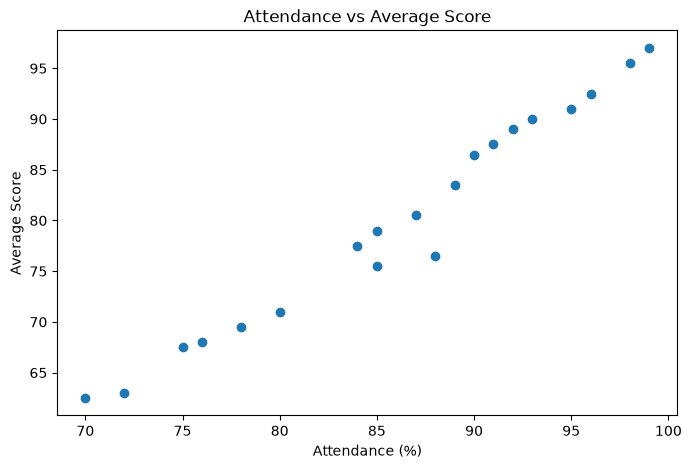

In [124]:
# ============================================================
# CHART 2: ATTENDANCE VS AVERAGE SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance"],
    df["Average_Score"]
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")

plt.show()

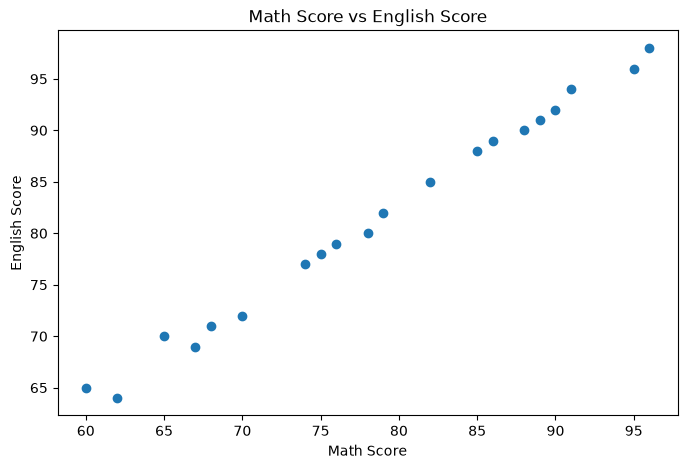

In [125]:
# ============================================================
# CHART 3: MATH SCORE VS ENGLISH SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Math_Score"],
    df["English_Score"]
)

plt.title("Math Score vs English Score")
plt.xlabel("Math Score")
plt.ylabel("English Score")

plt.show()

In [126]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation = df[
    [
        "Study_Hours",
        "Attendance",
        "Math_Score",
        "English_Score",
        "Average_Score"
    ]
].corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
               Study_Hours  Attendance  Math_Score  English_Score  \
Study_Hours           1.00        0.95        0.97           0.97   
Attendance            0.95        1.00        0.99           0.98   
Math_Score            0.97        0.99        1.00           1.00   
English_Score         0.97        0.98        1.00           1.00   
Average_Score         0.97        0.98        1.00           1.00   

               Average_Score  
Study_Hours             0.97  
Attendance              0.98  
Math_Score              1.00  
English_Score           1.00  
Average_Score           1.00  


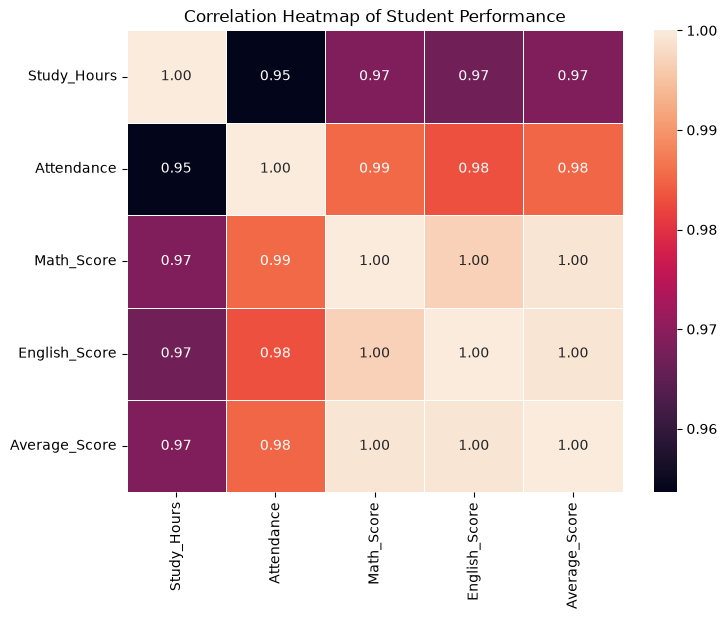

In [127]:
# ============================================================
# CHART 4: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Performance")
plt.show()

In [128]:
# ============================================================
# KEY INSIGHTS FROM CORRELATION ANALYSIS
# ============================================================

print("Correlation with Average Score:")
print(
    correlation["Average_Score"]
    .sort_values(ascending=False)
)

Correlation with Average Score:
Average_Score    1.000000
Math_Score       0.999255
English_Score    0.999186
Attendance       0.984994
Study_Hours      0.968606
Name: Average_Score, dtype: float64


In [129]:
# ============================================================
# PROJECT INSIGHTS
# ============================================================

print("KEY INSIGHTS")
print("=" * 50)

print(
    "1. Students with higher study hours generally tend "
    "to have higher average scores."
)

print(
    "2. Higher attendance is generally associated with "
    "better academic performance."
)

print(
    "3. Math and English scores show a positive relationship, "
    "indicating that students performing well in one subject "
    "often perform well in the other."
)

print(
    "4. The top-performing students can be identified using "
    "their Average_Score."
)

print(
    "5. Study habits and attendance can be important factors "
    "related to student academic performance."
)

KEY INSIGHTS
1. Students with higher study hours generally tend to have higher average scores.
2. Higher attendance is generally associated with better academic performance.
3. Math and English scores show a positive relationship, indicating that students performing well in one subject often perform well in the other.
4. The top-performing students can be identified using their Average_Score.
5. Study habits and attendance can be important factors related to student academic performance.


In [130]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("FINAL PROJECT SUMMARY")
print("=" * 50)

print("Total Students Analyzed:", len(df))

print(
    "Overall Average Score:",
    round(df["Average_Score"].mean(), 2)
)

print(
    "Average Study Hours:",
    round(df["Study_Hours"].mean(), 2)
)

print(
    "Average Attendance:",
    round(df["Attendance"].mean(), 2)
)

print("\nTop Performing Student:")

top_student = df.loc[df["Average_Score"].idxmax()]

print(
    "Student ID:",
    int(top_student["Student_ID"])
)

print(
    "Average Score:",
    round(top_student["Average_Score"], 2)
)

print("\nAnalysis completed successfully!")

FINAL PROJECT SUMMARY
Total Students Analyzed: 20
Overall Average Score: 80.15
Average Study Hours: 4.85
Average Attendance: 86.15

Top Performing Student:
Student ID: 16
Average Score: 97.0

Analysis completed successfully!
